In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
# Large Margin Classification

from sklearn.svm import SVC
from sklearn import datasets

iris = datasets.load_iris()
X = iris["data"][:, (2, 3)] # petal length, petal width
y = iris["target"]

setosa_or_versicolor = (y==0) | (y==1)
X = X[setosa_or_versicolor]
y = y[setosa_or_versicolor]

# SVM Classifier model
svm_clf = SVC(kernel="linear", C=float("inf"))
svm_clf.fit(X, y)

SVC(C=inf, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='scale', kernel='linear',
    max_iter=-1, probability=False, random_state=None, shrinking=True,
    tol=0.001, verbose=False)

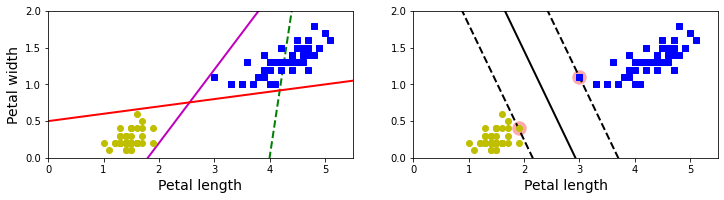

In [3]:
# Bad models

import numpy as np

x0 = np.linspace(0, 5.5, 200)
pred_1 =  5*x0 - 20
pred_2 = x0 - 1.8
pred_3 = 0.1 * x0 + 0.5

def plot_svc_decision_boundary(svm_clf, xmin, xmax):
    w = svm_clf.coef_[0]
    b = svm_clf.intercept_[0]
    
    # At the decision boundary, w0*x0 + w1*x1 + b = 0
    # => x1 = -w0/w1 * x0 - b/w1
    x0 = np.linspace(xmin, xmax, 200)
    decision_boundary = -w[0]/w[1] * x0 - b/w[1]
    
    margin = 1/w[1]
    gutter_up = decision_boundary + margin
    gutter_down = decision_boundary - margin
    
    svs = svm_clf.support_vectors_
    plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='#FFAAAA')
    plt.plot(x0, decision_boundary, "k-", linewidth=2)
    plt.plot(x0, gutter_up, "k--", linewidth=2)
    plt.plot(x0, gutter_down, "k--", linewidth=2)
    
plt.figure(figsize=(12, 2.7))

plt.subplot(121)
plt.plot(x0, pred_1, "g--", linewidth=2)
plt.plot(x0, pred_2, "m-", linewidth=2)
plt.plot(x0, pred_3, "r-", linewidth=2)
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Iris-Versicolor")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Iris-Setosa")
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.axis([0, 5.5, 0, 2])

plt.subplot(122)
plot_svc_decision_boundary(svm_clf, 0, 5.5)
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo")
plt.xlabel("Petal length", fontsize=14)
plt.axis([0, 5.5, 0, 2])
plt.show()

# on left:
# dashed line = basically useless decision boundary
# solid lines = OK for this dataset, but no margins. Probably will no

# On right:SVM finds widest possible "street" between classes

In [4]:
svm_clf.intercept_[0]

-3.7882347112962464

In [5]:
svm_clf.coef_

array([[1.29411744, 0.82352928]])

(0.0, 6.0, 0.0, 90.0)

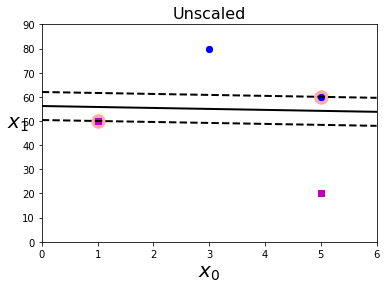

In [6]:
# Linear SVM Classification - Example - Without Scaling

Xs = np.array([[1, 50], [5, 20], [3, 80], [5, 60]]).astype(np.float64)
ys = np.array([0, 0 , 1, 1])
plt.plot(Xs[:, 0][ys==1], Xs[:, 1][ys==1], "bo")
plt.plot(Xs[:, 0][ys==0], Xs[:, 1][ys==0], "ms")

svm_clf = SVC(kernel="linear", C=100)
svm_clf.fit(Xs, ys)

plt.plot(Xs[:, 0][ys==1], Xs[:, 1][ys==1], "bo")
plt.plot(Xs[:, 0][ys==0], Xs[:, 1][ys==0], "ms")
plot_svc_decision_boundary(svm_clf, 0, 6)
plt.xlabel("$x_0$", fontsize=20)
plt.ylabel("$x_1$", fontsize=20, rotation=0)
plt.title("Unscaled", fontsize=16)
plt.axis([0, 6, 0, 90])

In [7]:
print("Original features properties")
print(Xs[:, 0].mean())
print(Xs[:, 0].std())
print(Xs[:, 1].mean())
print(Xs[:, 1].std())
print((Xs[:, 0]-Xs[:, 0].mean())/Xs[:, 0].std())
print((Xs[:, 1]-Xs[:, 1].mean())/Xs[:, 1].std())
      

Original features properties
3.5
1.6583123951777
52.5
21.650635094610966
[-1.50755672  0.90453403 -0.30151134  0.90453403]
[-0.11547005 -1.5011107   1.27017059  0.34641016]


In [8]:
# Linear SVM Classification - Example - With Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(Xs)
print('Scaled features: ')
print(X_scaled)

Scaled features: 
[[-1.50755672 -0.11547005]
 [ 0.90453403 -1.5011107 ]
 [-0.30151134  1.27017059]
 [ 0.90453403  0.34641016]]


(-2.0, 2.0, -2.0, 2.0)

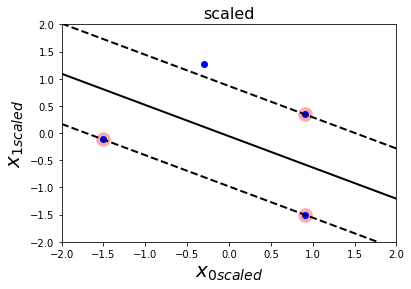

In [9]:
svm_clf.fit(X_scaled, ys)
plt.plot(X_scaled[:,0][ys==1], X_scaled[:, 1][ys==1], "bo")
plt.plot(X_scaled[:,0][ys==0], X_scaled[:, 1][ys==0], "bo")
plot_svc_decision_boundary(svm_clf, -2, 2)
plt.ylabel("$x_{1scaled}$", fontsize=20)
plt.xlabel("$x_{0scaled}$", fontsize=20)
plt.title("scaled", fontsize=16)
plt.axis([-2, 2, -2, 2])

# SVM are sensitive to feature scaling.
# Plot on right has much more robust feature boundary

In [10]:
svm_clf.coef_

array([[0.62225468, 1.0825318 ]])

(0.0, 5.5, 0.0, 2.0)

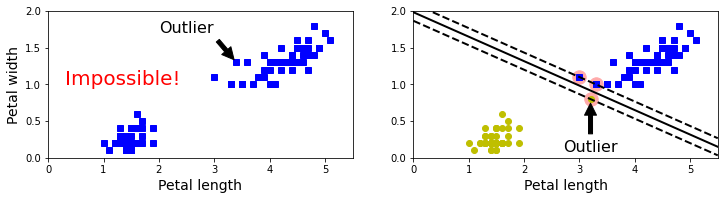

In [11]:
# "hard" margin classification:
# - all instances need to be "out of the street".
# - all instances need to be "on the right side of the street"
# problem: doable only if data is linearly separable
# problem: very sensitive to outliers

X_outliers = np.array([[3.4, 1.3],[3.2, 0.8]])
y_outliers = np.array([0, 0])
Xo1 = np.concatenate([X, X_outliers[:1]], axis=0)
yo1 = np.concatenate([y, y_outliers[:1]], axis=0)
Xo2 = np.concatenate([X, X_outliers[1:]], axis=0)
yo2 = np.concatenate([y, y_outliers[1:]], axis=0)

svm_clf2 = SVC(kernel="linear", C=10**9) #float("inf")
svm_clf2.fit(Xo2, yo2)

plt.figure(figsize=(12,2.7))

plt.subplot(121)
plt.plot(Xo1[:,0][yo1==1], Xo1[:, 1][yo1==1], "bs")
plt.plot(Xo1[:,0][yo1==0], Xo1[:, 1][yo1==0], "bs")
plt.text(0.3, 1.0, "Impossible!", fontsize=20, color="red")
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.annotate("Outlier",
            xy = (X_outliers[0][0], X_outliers[0][1]),
            xytext = (2.5, 1.7),
            ha="center",
            arrowprops=dict(facecolor='black', shrink=0.1),
            fontsize=16,
            )

plt.axis([0, 5.5, 0, 2])

plt.subplot(122)
plt.plot(Xo2[:,0][yo2==1], Xo2[:,1][yo2==1], "bs")
plt.plot(Xo2[:,0][yo2==0], Xo2[:,1][yo2==0], "yo")
plot_svc_decision_boundary(svm_clf2, 0, 5.5)
plt.xlabel("Petal length", fontsize=14)
plt.annotate("Outlier",
            xy = (X_outliers[1][0], X_outliers[1][1]),
            xytext = (3.2, 0.08),
            ha="center",
            arrowprops=dict(facecolor='black', shrink=0.1),
            fontsize=16,
            )
plt.axis([0, 5.5, 0, 2])

In [12]:
# SVM Classification - Soft Margin

from sklearn import datasets
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt

iris = datasets.load_iris()
X = iris["data"][:, [2,3]]
y = (iris["target"]==2).astype(np.float64)

In [13]:
scaler = StandardScaler()
svm_clf1 = LinearSVC(C=1, loss="hinge")

scaled_svm_clf1 = Pipeline([
    ("scaler", scaler),
    ("linear_svc", svm_clf1)
])

scaled_svm_clf1.fit(X, y)

Pipeline(memory=None,
        steps=[('scaler',
               StandardScaler(copy=True, with_mean=True, with_std=True)),
              ('linear_svc',
              LinearSVC(C=1, class_weight=None, dual=True,
                       fit_intercept=True, intercept_scaling=1,
                        loss='hinge', max_iter=1000, multi_class='ovr',
                        penalty='l2', random_state=None, tol=0.0001,
                        verbose=0))],
        verbose=False)

Pipeline(memory=None,
         steps=[('scaler',
                 StandardScaler(copy=True, with_mean=True, with_std=True)),
                ('linear_svc',
                 LinearSVC(C=1, class_weight=None, dual=True,
                           fit_intercept=True, intercept_scaling=1,
                           loss='hinge', max_iter=1000, multi_class='ovr',
                           penalty='l2', random_state=None, tol=0.0001,
                           verbose=0))],
         verbose=False)

In [14]:
scaled_svm_clf1.predict([[5.5, 1.7]])
array([1.])

NameError: name 'array' is not defined

In [15]:
b2 = svm_clf1.decision_function([-scaler.mean_ / scaler.scale_])
w2 = svm_clf1.coef_[0] / scaler.scale_
svm_clf1.intercept_ = np.array([b2])
svm_clf1.coef_ = np.array([w2])

In [ ]:
t = y * 2 -1
support_vectors_idx2 = (t* (X.dot(w2)+ b2)<1).ravel()
svm_clf1.support_vectors_ = X[support_vectors_idx2]

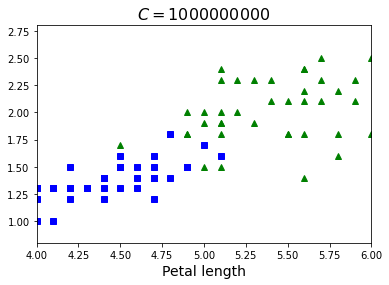

In [16]:
plt.plot(X[:,0][y==1], X[:,1][y==1], "g^")
plt.plot(X[:,0][y==0], X[:,1][y==0], "bs")
plot_svc_decision_boundary(svm_clf2, 4, 6)
plt.xlabel("Petal length", fontsize=14)
plt.title("$C = {}$".format(svm_clf2.C), fontsize=16)
plt.axis([4, 6, 0.8, 2.8])
plt.show()

In [ ]:
# The decision boundaries in a Support Vector machine is fully determined (or “supported”) by the instances located 
# on the edge of the street? - True

# Support Vector Machines are not sensitive to feature scaling - False

# A smaller C value leads to a wider street but more margin violations. - True

# If your SVM model is overfitting, you can try regularizing it by reducing the value of C hyper parameter

# The hyperparameter coef0 of SVC controls how much the model is influenced by high-degree polynomials versus
# low-degree polynomials - True

# A similarity function like Gaussian Radial Basis Function is used to Measure how much each instance resembles a 
# particular landmark

# When adding features with similarity function, and creating a landmark at the location of each and every instance in 
# the training set, a training set with m instances and n features gets transformed to (assuming you drop the original 
# features)
# ANS : A training set with m instances and m features

# When using SVMs we can apply an almost miraculous mathematical technique for adding polynomial features and similarity 
# features called the Kernel trick

# Which is right for the gamma parameter of SVC which acts as a regularization hyperparameter
# ANS: If model is overfitting, reduce it, if it is underfitting, increase it

# LinearSVC is much faster than SVC(kernel="linear")) - True

# In SVM regression the model tries to Fit as many instances as possible on the street while limiting margin violations

# The SVR class is the regression equivalent of the SVC class, and the LinearSVR class is the regression equivalent of the 
# LinearSVC class - True